# Flat-field events check (DL2-based)

Same goal as before - track how the standard-data flat-field intensity (charge) evolves over runs - but based on **DL2** files instead of DL1, since DL2 is merged per run. This means one file open per run instead of looping over every subrun.

Loops over all runs in the selection.

#### Imports

In [1]:
import os, glob, time
import numpy as np
import tables
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from pathlib import Path
from matplotlib import cm
import pandas as pd
pd.set_option('display.max_columns', None)


#### Paths and parameters

In [2]:
root_dl2 = "/fefs/onsite/data/lst-pipe/LSTN-01/DL2/????????/v*/tailcut*/nsb_tuning_*/"
file_srun_ly = "./data/selection/final_srw_ly3.ecsv"   # run/srun selection used for this analysis

# Intensity bins used to track the distribution shape over time (log-spaced, fixed across all runs
# so histograms are directly comparable run to run).
N_BINS = 60
INTENSITY_MIN, INTENSITY_MAX = 50, 2e5
intensity_bins = np.logspace(np.log10(INTENSITY_MIN), np.log10(INTENSITY_MAX), N_BINS + 1)


#### Run list

DL2 is merged per run, so we only need the list of unique runs (no subrun bookkeeping needed).

In [3]:
df_relation_runs = pd.read_csv(file_srun_ly, comment="#", sep=r"\s+")
obs_ids = sorted(int(r) for r in df_relation_runs["runnumber"].unique())

print(f"{len(obs_ids)} runs in the selection")


57 runs in the selection


#### Helpers

In [4]:
def find_dl2_file(obs_id):
    """
    Return the path to the (merged, run-wise) DL2 file for a given run, or None if not found.
    NOTE: root_dl2 includes a wildcard over nsb_tuning_*, so in principle more than one match is
    possible if several NSB-tuning versions were produced for the same run; we just take the first one.
    """
    matches = glob.glob(os.path.join(root_dl2, f"dl2_LST-1.Run{obs_id:05}.h5"))
    return matches[0] if matches else None


def load_flatfield_intensity(filepath):
    """Open a DL2 file and return the intensity array of its flat-field events (event_type == 0)."""
    with tables.open_file(filepath) as f:
        table = f.root.dl2.event.telescope.parameters.LST_LSTCam
        event_type = table.col("event_type")
        intensity = table.col("intensity")
    return intensity[event_type == 0]


#### Loop over all runs

For each run, summarize its flat-field intensities as:
- a histogram over `intensity_bins` (for the distribution-over-time plot)
- median / 16th / 84th percentile / n_events (for a simple trend line)

In [5]:
t0 = time.time()

run_summaries = []
run_histograms = []
missing_runs = []

for i, obs_id in enumerate(obs_ids):
    filepath = find_dl2_file(obs_id)
    if filepath is None:
        missing_runs.append(obs_id)
        continue

    run_intensity = load_flatfield_intensity(filepath)
    if len(run_intensity) == 0:
        continue

    counts, _ = np.histogram(run_intensity, bins=intensity_bins)

    run_summaries.append({
        "obs_id": obs_id,
        "n_events": len(run_intensity),
        "median": np.median(run_intensity),
        "p16": np.percentile(run_intensity, 16),
        "p84": np.percentile(run_intensity, 84),
    })
    run_histograms.append(counts)
    print(f" -> Reading runs... ({i + 1}/{len(obs_ids)})", end="\r")

print(f"\nDone in {time.time() - t0:.0f}s. "
      f"{len(run_summaries)} runs with flatfield data, {len(missing_runs)} missing DL2 files.")

df_runs = pd.DataFrame(run_summaries).sort_values("obs_id").reset_index(drop=True)
hist_matrix = np.array(run_histograms)[df_runs.index]


 -> Reading runs... (57/57)
Done in 800s. 57 runs with flatfield data, 0 missing DL2 files.


In [6]:
ROOT       = Path(os.getcwd())
ROOT_DATA  = ROOT / "data"
DCHECK_DIR = ROOT_DATA / "datachecks"
FNAME_TABLE_SRUN  = DCHECK_DIR / "table_datachecks_srunwise.csv"

df = pd.read_csv(FNAME_TABLE_SRUN)
df["timestamp"] = pd.to_datetime(df["timestamp"])

dff = df[df['obs_id'].isin(df_runs['obs_id'])]


print(f"Loaded {len(df):} runs from {FNAME_TABLE_SRUN.name}")
print(f"Date range: {df['timestamp'].min().date()} -> {df['timestamp'].max().date()}")
df.head(3)

Loaded 12692 runs from table_datachecks_srunwise.csv
Date range: 2019-11-24 -> 2026-05-21


,obs_id,n_subruns,timestamp,telapsed,az,zd,ra,dec,cosmics_peak_rate,stdv_cosmics_peak_rate,cosmics_rate_at_422_pe,stdv_cosmics_rate_at_422_pe,intensity_at_half_peak_rate,stdv_intensity_at_half_peak_rate,delta_cosmics_rate_at_422_pe,stdv_delta_cosmics_rate_at_422_pe,cosmics_spectral_index,stdv_cosmics_spectral_index,delta_cosmics_spectral_index,stdv_delta_cosmics_spectral_index,ZD_corrected_cosmics_peak_rate,stdv_ZD_corrected_cosmics_peak_rate,ZD_corrected_cosmics_rate_at_422_pe,stdv_ZD_corrected_cosmics_rate_at_422_pe,ZD_corrected_intensity_at_half_peak_rate,stdv_ZD_corrected_intensity_at_half_peak_rate,ZD_corrected_delta_cosmics_rate_at_422_pe,stdv_ZD_corrected_delta_cosmics_rate_at_422_pe,ZD_corrected_cosmics_spectral_index,stdv_ZD_corrected_cosmics_spectral_index,intensity_spectrum_fit_p_value,stdv_intensity_spectrum_fit_p_value,diffuse_nsb_std,stdv_diffuse_nsb_std,charge_mean,stdv_charge_mean,light_yield,stdv_light_yield,run_drdi_fit_p0,run_drdi_fit_p1,run_drdi_fit_u_p0,run_drdi_fit_u_p1,run_drdi_fit_chi2,run_drdi_fit_pvalue,run_drdi_fit_ndf,run_drdi_fit_error_flag,temperature,pressure,humidity,wind_speed,wind_gust,wind_speed_average,tng_dust,tng_seeing,rain
0,1620,78,2019-11-24 02:03:06.030581,1748.229183,148.833255,8.163757,83.531399,21.910342,7.611171,0.110524,2.089467,0.023610,125.458750,1.256382,0.021311,0.008644,-2.126284,0.056428,0.061951,0.024968,7.758958,0.123232,2.099011,0.025127,125.248930,1.242042,0.021409,0.008685,-2.123014,0.056518,0.397674,0.266095,1.695722,0.011298,2.125367,0.013828,1.182556,0.018580,2.134920,-0.000044,0.004465,0.000004,87.920147,0.165050,76,False,7.733974,785.949103,57.757564,15.726538,22.882051,16.961667,0.030000,2.375385,0.0
1,1621,41,2019-11-24 02:46:26.059253,906.620067,115.472338,15.059591,102.534431,21.601340,7.663080,0.109139,2.102083,0.022761,126.574147,1.348813,0.021243,0.007777,-2.128735,0.069207,0.061361,0.022319,8.189763,0.127527,2.136021,0.022300,125.872918,1.324374,0.021585,0.007892,-2.117499,0.069495,0.387120,0.278909,1.739242,0.002279,2.165937,0.003424,1.202537,0.020547,2.144476,-0.000025,0.006905,0.000011,55.309977,0.043499,39,False,7.554390,785.751951,45.502195,13.881463,19.723415,14.387561,0.030000,2.240000,0.0
2,1622,79,2019-11-24 03:07:34.524597,1779.822174,238.919513,12.425440,83.675559,22.003357,7.547142,0.109935,2.070015,0.022596,126.127736,1.213011,0.019206,0.007936,-2.126282,0.060380,0.056331,0.023017,7.897071,0.130765,2.092585,0.020276,125.642173,1.186493,0.019417,0.008023,-2.118594,0.060501,0.466875,0.294387,1.704910,0.021975,2.135173,0.025669,1.179990,0.015220,2.096437,-0.000010,0.003487,0.000004,89.365343,0.140139,76,False,7.642152,785.651899,49.364937,14.829620,20.784937,15.142152,0.037468,3.502152,0.0


#### FF intensity trend over runs

Median flat-field intensity per run (with the 16th-84th percentile band), in run-number order, which here is used as a proxy for chronological order.

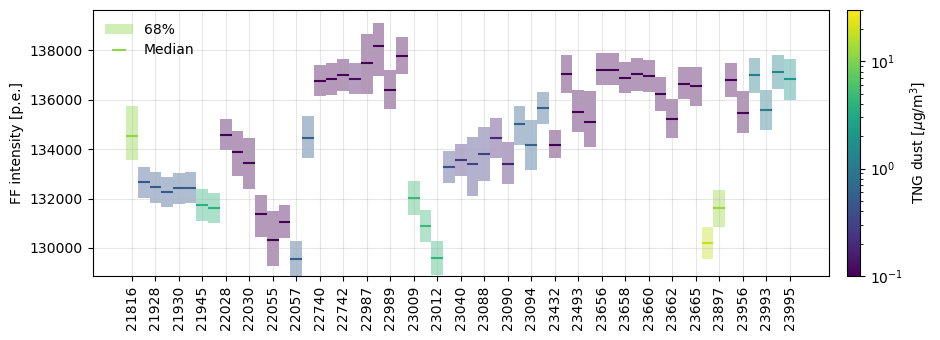

In [7]:
fig, ax = plt.subplots(figsize=(10, 3.5))

x = np.arange(len(df_runs))
cmap = plt.colormaps["viridis"]
vmin_val = max(1e-5, df["tng_dust"].min())
norm = colors.LogNorm(vmin=1e-1, vmax=30)
dust_vals = []
for ii in range(len(df_runs)):
    _df = df[df["obs_id"] == df_runs["obs_id"][ii]]
    dust_val = _df["tng_dust"].mean()
    dust_vals.append(dust_val)
    c = cmap(norm(dust_val))

    ax.bar(
        x[ii], bottom=df_runs["p16"][ii], height=df_runs["p84"][ii] - df_runs["p16"][ii],
        width=1.0, color=c, alpha=0.4, label="68%" if ii==0 else None, zorder=1,
    )

    ax.errorbar(x[ii], df_runs["median"][ii], ls="", marker="", xerr=0.5, color=c, label="Median" if ii==0 else None)

step = max(1, len(df_runs) // 20)
ax.set(xticks=x[::step], ylabel="FF intensity [p.e.]")
ax.set_xticklabels(df_runs["obs_id"].iloc[::step], rotation=90, ha="center")

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("TNG dust [$\\mu$g/m${^3}$]")
ax.legend(frameon=False); ax.grid(alpha=0.3); plt.tight_layout()
plt.show()

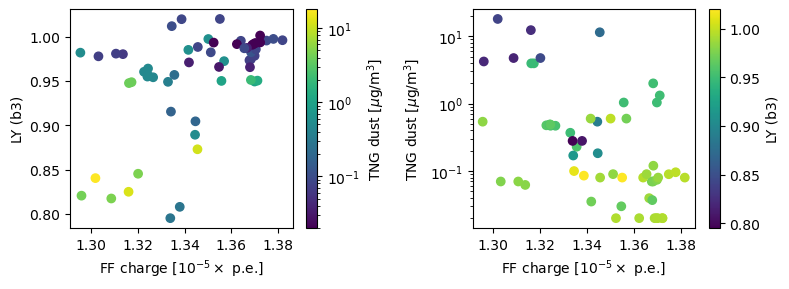

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))

sc1 = ax1.scatter(df_runs["median"]*1e-5, dff['light_yield'], c=dust_vals, norm=colors.LogNorm())
sc2 = ax2.scatter(df_runs["median"]*1e-5, dust_vals, c=dff['light_yield'])
fig.colorbar(sc1, ax=ax1, label="TNG dust [$\\mu$g/m${}^3$]")
fig.colorbar(sc2, ax=ax2, label="LY (b3)")

ax1.set(xlabel="FF charge [$10^{-5}\\times$ p.e.]", ylabel="LY (b3)")
ax2.set(xlabel="FF charge [$10^{-5}\\times$ p.e.]", ylabel="TNG dust [$\\mu$g/m${}^3$]", yscale="log")
plt.tight_layout()
plt.show()

In [9]:
import pickle
from pathlib import Path

# Adjust this path if your new notebook is in a different directory
FNAME_DCHECK_SRUN = Path("data/datachecks/dict_datachecks_srunwise.pkl")

with open(FNAME_DCHECK_SRUN, "rb") as f:
    dict_dcheck_srunwise = pickle.load(f)

print(f"Loaded {len(dict_dcheck_srunwise):,} runs successfully.")

Loaded 12,692 runs successfully.


In [12]:
file = "./data/selection/raw_srw_ly3.ecsv"

charge_map = df_runs.set_index("obs_id")["median"].to_dict()

df_relation_runs["ff_charge_mean"] = df_relation_runs["runnumber"].map(charge_map)

zds = []
for obs_id in obs_ids:
    _dict = dict_dcheck_srunwise[obs_id]
    _zds = []
    for s in _dict.keys():
        _zds.append(_dict[s]["mean_zenith_distance"])
    zds.append(_zds)
    
df_relation_runs["zd"] = np.concatenate(zds)

with open(file, "r") as f:
    comments = [line for line in f if line.startswith("#")]

with open(file, "w") as f:
    f.writelines(comments)
    df_relation_runs.to_csv(f, sep=",", index=False)

print(f"Successfully updated {file} with the 'ff_charge_mean' column.")
display(df_relation_runs.tail())

Successfully updated ./data/selection/raw_srw_ly3.ecsv with the 'ff_charge_mean' column.


,runnumber,srun,light_yield,ff_charge_mean,zd
5764,23995,119,0.945145,136831.031632,45.174729
5765,23995,120,0.945189,136831.031632,45.210575
5766,23995,121,0.945233,136831.031632,45.246452
5767,23995,122,0.945276,136831.031632,45.282323
5768,23995,123,0.945304,136831.031632,45.304382
